<div align="center">
    <h1><b></b></h1>
    <h1><b>Simulación<br>Clase 02 - Generación de Números Aleatorios</b></h1>
    <img alt="I&S" height="135px" src="https://raw.githubusercontent.com/juliancastillo-udea/AlDiSi/refs/heads/main/images/Logo%20AlDiSi_Horizontal%20UdeA%20II.png">
</div>

<hr size="10" noshade color="green">

<div>
    <img alt="CC" height="70px" src="https://raw.githubusercontent.com/juliancastillo-udea/2024-1-ProgramacionPosgrados/main/images/by.xlarge.png">
    <img alt="Attribution" height="70px" src="https://raw.githubusercontent.com/juliancastillo-udea/2024-1-ProgramacionPosgrados/main/images/nc.xlarge.png">
    <img alt="NC" height="70px" src="https://raw.githubusercontent.com/juliancastillo-udea/2024-1-ProgramacionPosgrados/main/images/sa.xlarge.png">
    <img alt="SA" height="70px" src="https://raw.githubusercontent.com/juliancastillo-udea/2024-1-ProgramacionPosgrados/main/images/cc-icons.png">
</div>

<div align="right">
    <h2><b>Por: Julián Andrés Castillo G.</b></h2>
    <a href="mailto:jandres.castillo@udea.edu.co">✉ Julian Andres Castillo Grisales</a>
    <h3><b>Monitor: Manuel Martínez.</b></h3>
    <a href="mailto:manuel.martinezl@udea.edu.co">✉ Manuel Martínez</a>
</div>

<br>

<div align="center">
    <p><b>El presente curso hace parte del área de Métodos Cuantitativos de Ingeniería Industrial de la Universidad de Antioquia.</b></p>
    <h1><b>Simulación Aquí Seguimos!!!</b></h1>
</div>


## **Librerías Necesarias**

In [9]:
from numpy import random as rnd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as mt
import sympy
import statistics as st
from tqdm import tqdm
from tqdm import trange
import time
from datetime import datetime as dt
import os

# **Números y variables aleatorias**

En muchos de los experimentos de muestreo y en los experimentos de simulación se requiere disponer de una fuente de números aleatorios o de un método para generarlos a medida que se necesiten.
Los números aleatorios son indispensables para representar todas las variaciones aleatorias del sistema, es decir, el comportamiento de las variables incontrolables, y son la base para realizar cualquier simulación.

**Un numero aleatorio es una variable aleatoria que sigue la distribución uniforme en el intervalo (0,1).**
Una variable aleatoria $X$ tiene una distribución uniforme en el intervalo $(a,b)$ si su función de densidad está dada por:
<h2>
$f(x) = \begin{cases} \frac{1}{b-a} & a\leq x\leq b, \\0 & x < a  \ ó\  x>b\end{cases}$
</h2>
La función de distribución $F(x)$, que representa la probabilidad de que la variable aleatoria $X$ sea menor o igual que un valor especifico $x$, esta definida como:
<h2>
$F(x) = \begin{cases} 0 & para \ x<b, \\\frac{x-a}{b-a} & para \ a\leq x < b, \\ 1 & para \ x\geq b \end{cases}$

</h2>

Tanto la PDF como la CDF se pueden ver a continuación para una distribución uniforme.

<img alt="pdfcdf" height="200px" src="https://raw.githubusercontent.com/juliancastillo-udea/Curso_Simulacion/refs/heads/main/images/pdf_CDF.png" hspace="10px" vspace="0px">


El valor esperado y la varianza de una distribución uniforme son los siguientes:
<h2>
$E(X) = \int_a^b x f(x) \, dx = \frac{a + b}{2}$
<h2>
$Var(X) = \int_a^b \left(x - E(x)\right)^2 f(x) \, dx = \frac{(x - a)^2}{12}$

Así, un numero aleatorio $R$ tiene una función de densidad dada por:

<h2>
$f(r) = 1 → 0 \leq r < 1$

La función de distribución está dada por:
<h2>
$F(r) =P(R \leq r)=r → 0 \leq r < 1$

El valor esperado y la varianza están dados por: $E(R)=  \frac{1}{2}$ , $Var(R) = \frac{1}{12}$

La variable aleatoria $R$ es continua y los valores generados deben ser estadísticamente independientes*.


*Dos sucesos aleatorios son independientes entre sí cuando la probabilidad de cada uno de ellos no está influida porque el otro suceso ocurra o no.

Es posible que en algún procedimiento de generación de números aleatorios la variable $R$ esté designando un número finito de valores $-N-$, equiprobables y estadísticamente independientes. En este caso $R$ es discreta y su función de probabilidad y de distribución están dadas por:

<h2>
$f(r) = \frac{1}{N} \quad 0 \leq r < 1$
<h2>
$F(r) = \frac{r}{N} \quad 0 \leq r < 1$

Para los experimentos de simulación generalmente se requiere de secuencias grandes de números aleatorios, no solamente unos pocos. Los números aleatorios generados en esta secuencia deben ser independientes.

Estamos interesados en determinar métodos para generar estos números. Estos métodos deben cumplir ciertas condiciones para que sean eficientes y para que las secuencias generadas sean en realidad aleatorias.

Estos métodos los denominaremos “Generadores de Números Aleatorios” o simplemente “Generadores”.

Las propiedades que debe tener un generador de números aleatorios son las siguientes:
1.   Los números generados deben estar distribuidos uniformemente entre cero y uno.
2.   Los números generados deben ser estadísticamente independientes.
3.   Las secuencias generadas deben ser reproducibles de tal forma que los diferentes experimentos de simulación se puedan repetir bajo las mismas condiciones.
4.   El método debe poseer un período largo. El período de un generador de números aleatorios indica la cantidad de números aleatorios que se pueden generar en una secuencia antes de que estos comiencen a repetirse. El período está asociado con la reproducibilidad. Si las secuencias no son reproducibles, entonces no puede hablarse de período. El período debe ser lo suficientemente largo de tal forma que en un mismo experimento de simulación no se repita la secuencia de números aleatorios.
5.   Eficiencia. El método debe requerir el mínimo tiempo para generar un número aleatorio, es decir, debe generar números a grandes velocidades.
6.   El método debe requerir una mínima capacidad de almacenamiento.
7.   Portabilidad. El método debe ser tal que se pueda transportar de una máquina a otra, sin ninguna complicación.

Las dos primeras condiciones están asociadas con las condiciones básicas de un generador de números aleatorios: **Uniformidad** e **independencia**. Si un método cumple estas dos condiciones, se lo puede considerar como un generador de números aleatorios.

Las condiciones tercera y cuarta son básicas para poder comparar diferentes alternativas en una simulación, de tal forma que las diferencias en los resultados de una simulación se puedan explicar por las diferencias entre las alternativas, y no por las variaciones aleatorias.

En algunos estudios de simulación se requieren miles y a veces millones de números aleatorios, y debemos garantizar que la mayor parte del tiempo de la simulación no se utilice en la generación de los números sino en los otros procesos del sistema.

En general, un generador de números aleatorios debe ser un programa corto y rápido que produzca una secuencia larga de números antes de que empiece de nuevo el ciclo.

Para diseñar un buen generador de números aleatorios se deben seguir dos pasos o etapas:
*   El primer paso consiste en definir el método a usar para generar los números
*   El segundo consiste en definir el conjunto o batería de pruebas estadísticas a que se debe someter el generador para garantizar las propiedades estadísticas de los números generados.

Para generar números aleatorios se pueden usar diferentes procedimientos, siempre y cuando garanticen que se cumplen las condiciones básicas de uniformidad e independencia. La exigencia de las demás condiciones depende del uso que se le vaya a dar al generador. A continuación, se hará un recuento de los diferentes métodos empleados, pero se hará énfasis en los utilizados actualmente.


## **Métodos Manuales**
Son los métodos más simples y despaciosos. Incluye el lanzamiento de monedas, dados, cartas y ruletas. Los números producidos por estos métodos cumplen las condiciones estadísticas básicas, pero es imposible reproducir una secuencia generada por estos métodos.
<img alt="pdfcdf" height="300px" src="https://raw.githubusercontent.com/juliancastillo-udea/Curso_Simulacion/refs/heads/main/images/Ruleta.jpg" hspace="10px" vspace="0px">


## **Tablas de Números Aleatorios**
Estos números fueron generados por otros métodos y sometidos a diferentes pruebas estadísticas de uniformidad e independencia. La ventaja del método consiste en que las secuencias siempre son reproducibles y son muy apropiados para simulaciones de tipo manual. Sin embargo tiene la desventaja de no realizarse con rapidez. Además, para simulaciones por computador requeriría mucho almacenamiento, fuera de que el proceso de lectura de los datos es muy despacioso.

Una de las tablas más conocidas es la de la RandCorporation [“Un Millón de Números Aleatorios”](https://www.rand.org/content/dam/rand/pubs/monograph_reports/MR1418/MR1418.digits.pdf), que fue generada mediante el computador análogo. Para usar una tabla de números aleatorios, se debe definir un punto inicial de partida, y la dirección en que se van a seleccionar los números. Estos deben escogerse siguiendo el orden determinado de antemano.

<img alt="pdfcdf" height="400px" src="https://raw.githubusercontent.com/juliancastillo-udea/Curso_Simulacion/refs/heads/main/images/oneMillionRandomNumbers.png" hspace="10px" vspace="0px">




## **Mediante el computador análogo**
Estos métodos dependen de ciertos procesos físicos aleatorios en el computador, por ejemplo, el comportamiento de una corriente eléctrica. Se considera que estos métodos producen verdaderos números aleatorios y son mucho más rápidos que los manuales o las tablas, pero las sucesiones de números no son reproducibles.

Los números aleatorios de la RandCorporation fueron generados mediante este método. Los números deben someterse a un conjunto de pruebas estadísticas para verificar uniformidad e independencia.

<img alt="pdfcdf" height="300px" src="https://raw.githubusercontent.com/juliancastillo-udea/Curso_Simulacion/refs/heads/main/images/AnalogComputerRandomNumbers.png" hspace="10px" vspace="0px">


## **Mediante el computador digital**
Esta alternativa comprende la generación de números “pseudoaleatorios” por medio de una transformación aplicada a un grupo de números elegidos de una manera arbitraria.
Se habla de números “pseudoaleatorios” ya que, estrictamente hablando, estos números no son aleatorios, pero se comportan como si lo fueran.

Estos números son generados por métodos completamente determinísticos y no presentan el problema de lectura ni de la capacidad de almacenamiento.

La principal objeción a estos métodos radica en aspectos un tanto filosóficos respecto a que una sucesión de números producidos por métodos completamente determinísticos resulta ser la antítesis directa de una secuencia aleatoria. Sin embargo, esta objeción puede superarse si se someten los generadores a un conjunto de pruebas estadísticas para verificar la uniformidad e independencia de las series producidas por estos métodos.

Generalmente mediante estos métodos se generan inicialmente números enteros y luego se normalizan en el rango cero uno mediante la transformación apropiada, dividiendo por un valor tal que la serie resultante quede entre cero y uno.

En contexto hablaremos en forma genérica de números “aleatorios”, bien sea que nos estemos refiriendo a números aleatorios estrictamente hablando o a números pseudoaleatorios.

A nivel meramente ilustrativo mencionaremos los primeros métodos usados para generar números pseudoaleatorios, como son los métodos de los cuadrados y los productos centrales, y luego enfatizaremos en los métodos usados actualmente, basados en las relaciones de congruencia.


<img alt="pdfcdf" height="300px" src="https://raw.githubusercontent.com/juliancastillo-udea/Curso_Simulacion/refs/heads/main/images/ModernPC.jpg" hspace="10px" vspace="0px">

# **Métodos de los cuadrados centrales**

Este es uno de los primeros métodos empleados para generar números aleatorios mediante el computador (Von Neumann). Cada número de la secuencia se obtiene tomando las $k$ cifras centrales del cuadrado del número anterior. Si es necesario puede agregarse un cero (0) al principio o al final del cuadrado del número, de tal forma que el número generado siempre tenga $k$ dígitos. Para generar el número aleatorio $R$ entre cero y uno, se divide el número de $k$ cifras por la máxima cantidad de números de $k$ cifras que pueda generarse ($M$). La función DC permite extraer los digitos centrales del valor calculado, es decir,


> <h1>$x_n= K \ cifras \ centrales \ de \ x_{n-1}^2 = DC(x_{n-1}^2)$</h1>
>
>>Para todo
>> <h2>$0 \leq x_n <M$</h2>
> Donde
>> <h2>$R_n= \frac{x_n}{M}$</h2> con $M=10^k$





Por lo tanto, para aplicar este método se deben definir dos parámetros: El número de dígitos $k$ y el primer número de $K$ cifras, $x_0$ , denominado la “semilla”.
Suponga que se desea generar números de tres cifras, es decir, que podrían generarse teóricamente hasta 1000 números diferentes $(000, 001, 002,…,998, 999)$. Además, es necesario especificar el número inicial o semilla. Sea este $721$. Por lo tanto:

*   $x_0=721 \rightarrow M=10^3 = 1000$
*   $x_1=(721*721)=DC(519841) = 198 \rightarrow R_1 = \frac{198}{1000}=0.198$
*   $x_2=(198*198)=DC(39204) = 920 \rightarrow R_2 = \frac{920}{1000}=0.920$
*   $x_3=(920*920)=DC(846400) = 464 \rightarrow R_3 = \frac{464}{1000}=0.464$
*   $x_4=(464*464)=DC(215296) = 152 \rightarrow R_4 = \frac{152}{1000}=0.152$
*   $...$




Este método tiene tendencia a degenerarse rápidamente, dependiendo del valor inicial, y no puede lograrse el período completo $(h < M)$. Por ejemplo, si $x_0 = 10$, entonces $x_1=10$, $x_2=10$, $x_3=10$.
Además, este método es relativamente lento y estadísticamente insatisfactorio.

Veamos el algoritmo y su comportamiento usando [TimeStamp](https://en.wikipedia.org/wiki/Timestamp#:~:text=A%20timestamp%20is%20a%20sequence,small%20fraction%20of%20a%20second.)

In [ ]:
timestamp = dt.timestamp(dt.now())
print(timestamp)

In [ ]:
for i in range(10):
    timestamp = dt.timestamp(dt.now())
    print(timestamp)

## **Convergencia del promedio**

In [ ]:
#Calcular Convergencia del promedio

## **Convergencia de la varianza**

In [ ]:
#Calcular Convergencia de la varianza

# **Aproximacion dos al Método de los cuadrados centrales**



In [ ]:
# Modelo

In [ ]:
#Calcular Convergencia del promedio

In [ ]:
#Calcular Convergencia de la varianza

# **Métodos de los productos centrales**

Este método es una variante del anterior, pero el número resultante se genera como las $k$ cifras centrales del producto de los dos números generados previamente. Es decir,



> <h1>$x_n= DC(x_{n-1}*x_{n-2})$</h1>
>
>>Para todo
>> <h2>$0 \leq x_n <M$</h2>
> Donde
>> <h2>$R_n= \frac{x_n}{M}$</h2> con $M=10^k$





In [ ]:
def SoyPrimo(n:int)->bool:
    """
    Verifica si un número dado es primo. (Esto será muy útil 👀)

    Parameters:
    n (int): El número entero a verificar.

    Returns:
    bool: True si el número es primo, False en caso contrario.
    """

    if n <= 1:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0:
            return False
    return True

## **Convergencia del promedio**

In [ ]:
#Calcular Convergencia del promedio

## **Convergencia de la varianza**

In [ ]:
#Calcular Convergencia de la varianza

# **Generadores Congruenciales**

Estos son los métodos que se usan actualmente, bien sea en su forma original, o mediante a combinación de diferentes generadores.
Los métodos congruenciales para generar números aleatorios son completamente determinísticos debido a que el proceso aritmético involucrado en el cálculo determina unívocamente cada término de la secuencia de números. En efecto, existen fórmulas para calcular por adelantado el i -ésimo término de la secuencia ${\{𝑥_0,𝑥_1,𝑥_2,…,𝑥_𝑖,….\}}$ sin que se hayan calculado los términos anteriores.

Aunque la secuencia de números así generada no sea estrictamente aleatoria, puede considerarse como tal si satisface un conjunto de pruebas estadísticas sobre aleatoriedad, es decir, si se puede demostrar estadísticamente que los números generados se distribuyen uniformemente y son independientes.



## **Método Congruencial**

Los métodos congruenciales están basados en la relación fundamental de congruencia que puede expresarse por medio de la siguiente ecuación recursiva:

<h1>
$x_i = (a*x_{i-1}+C) \ Módulo \ M$

</h1>

Donde:
*   $a, \ x_{i-1}, \ C \ y \ M$ Son enteros no negativos
*   $a, \ x_{i-1}, \ C \ < \ M$
*   $M$ debe ser $2^k$ con $k$ entero

Para poder entender claramente la relación fundamental de congruencia y su utilización en la generación de números aleatorios es necesario tener en cuenta las siguientes definiciones.



## **Resto y Residuo**

><img alt="CC" height="200px" src="https://raw.githubusercontent.com/juliancastillo-udea/Curso_Simulacion/refs/heads/main/images/RestoResiduo1.png" align="left" hspace="0px" vspace="0px">

><img alt="CC" height="200px" src="https://raw.githubusercontent.com/juliancastillo-udea/Curso_Simulacion/refs/heads/main/images/RestoResiduo2.png" align="left" hspace="0px" vspace="0px">

## **Relación de Congruencia**

Dos enteros $A$ y $B$ son congruentes con módulo $M$ si su diferencia es un múltiplo de $M$. La relación de congruencia se expresa mediante la notación $A \equiv B \rightarrow Mod \ M$, que se lee "$A$ es congruente con $B$ módulo de $M$". El hecho de que dos enteros $A$ y $B$ sean congruentes módulo $M$ significa que:
1.   $\mid A-B\mid$ es divisible por $M$, es decir, $\frac{\mid A-B\mid}{M}=entero=k$
2.   $A$ y $B$ generan el mismo residuo al ser divididas por el módulo $M$, es decir, $Residuo \left( \frac{A}{M} \right)=Residuo \left( \frac{B}{M} \right)$
---
>Ejemplo: $127$ y $238$ son congruentes módulo 100.
>>$Residuo \left( \frac{127}{100} \right)=27$
>>$Residuo \left( \frac{238}{100} \right)=38$
>>
>>Resultado: $127$ y $238$ **NO** son congruentes módulo 100
---
>Ejemplo: $115$ y $435$ son congruentes módulo 80.
>>$Residuo \left( \frac{115}{80} \right)=35$
>>$Residuo \left( \frac{435}{80} \right)=35$
>>
>>Resultado: $127$ y $238$ **SI** son congruentes módulo 80
>>
>>Aplicando la primera definición se tiene:
>>$\frac{\mid 435-115\mid}{80}=\frac{320}{80}=4$
>>
>>$115 \equiv 435 \ mod \ 80$
---

¿Cómo encontrar un número $B$ que sea congruente con otro número dado $A$ módulo $M$?

El método mas sencillo sería dividir el número $A$ por el módulo $M$ y tomar el residuo como el número $B$ buscado, o también, tomar el residuo mas un número entero $k$ de veces el módulo o menos un número entero de veces el módulo. Esto ya que si se divide $Residuo \left( \frac{A}{M} \right)=k*M$ por el módulo $M$ se obtiene el mismo residuo.
>
>$B \equiv Residuo \left( \frac{A}{M} \right) \equiv Residuo \left( \frac{A}{M} \right) +M \equiv Residuo \left( \frac{A}{M} \right) + 2M,...,\equiv Residuo \left( \frac{A}{M} \right) + k*M$
>
>Ejemplo:
>>$55 \equiv 5 \ mod \ 10 → 55 \equiv 15  \ mod \  10→55 \equiv 25  \ mod \  10→55 \equiv 95  \ mod \  10→55≡185  \ mod \  10$

Otra forma sería sumarle o restarle $k$ veces el módulo al número dado $A$. Si a un número $A$ se le suma o se le resta un número entero de veces el módulo la relación de congruencia no cambia ya que el residuo sigue siendo el mismo siendo $k$ entero.
>
>$𝐴 \equiv (𝐴+𝑀) \ mod \  𝑀 \equiv 𝐴 \equiv (𝐴−𝑀) \ mod \  𝑀 \equiv 𝐴 \equiv (𝐴+2𝑀) \ mod \  𝑀 \equiv 𝐴 \equiv (𝐴−2𝑀) \ mod \  𝑀 \equiv 𝐴 \equiv (𝐴±𝑘𝑀) \ mod \  𝑀$

Para encontrar un número que sea congruente con otro número negativo basta con sumarle el módulo cuantas veces sea necesario hasta que el número se vuelva positivo.

Para un número dado $A$ existen muchos otros números que sean congruentes con $A$ módulo $M$, como se observó anteriormente. Sin embargo, sólo existe un entero no negativo menor que $M$, (el residuo) que sea congruente con $A$ Módulo $M$, y es el que se usará para la generación de números aleatorios. Este aspecto se formaliza mediante la siguiente definición.






## **Generador Congruencial**

Para un valor dado $A$ el menor entero positivo $m$ que sea congruente con $A$ módulo $M$ $(m \equiv A \ mod \ M)$ recibe el nombre de "residuo de $A$ módulo $M$". Para un número dado $m$ existen entonces $M$ residuos diferentes $\{0, 1, 2,…, M−2, M−1\}$
Al conjunto de números enteros mutuamente congruentes con un residuo $M$ se le denomina "Clase residual módulo $M$”.

Retomando la relación fundamental de congruencia tenemos que:
$x_i \equiv (a*x_{i-1}+C) \ Módulo \ M$

Entonces para generar números aleatorios mediante esta relación, el valor de $x_i$ será el residuo módulo $M$ de la operación
será el residuo módulo M de la operación $a*x_{i-1}+C$, es decir:

$x_i = Residuo (a*x_{i-1}+C) \ Módulo \ M → 0 ≤ x_i < M $

Entonces:
Se tiene que $0 ≤ x_i < M $, entonces de la secuencia de enteros 𝑥_𝑖 se pueden obtener números racionales en el intervalo $(0,1)$ (números aleatorios) dividiendo $x_i$ por el módulo $M$, esto es,
$R_i = x_i/M → 0≤ r_i < 1$
El valor $M$ recibe el nombre de módulo, $a$ es el multiplicador, $C$ la constante aditiva y $x_0$ la semilla.



In [8]:
x0 = 3
M = 100
C = 7
a = 13
ri = []
for i in range(100):
    xi = a * x0 + C
    xi = xi % M
    x0 = xi
    r = xi/M
    ri.append(r)
    if ri[0] == r and len(ri) > 2:
        del ri[-1]
        break
for indice, numero in enumerate(ri,1):
    print(str(indice).zfill(0), f'\t{numero}')

1 	0.46
2 	0.05
3 	0.72
4 	0.43
5 	0.66
6 	0.65
7 	0.52
8 	0.83
9 	0.86
10 	0.25
11 	0.32
12 	0.23
13 	0.06
14 	0.85
15 	0.12
16 	0.63
17 	0.26
18 	0.45
19 	0.92
20 	0.03


### **Ejemplo Congruencial**

Usando --> $x_i = (ax_{i-1} + C) \ Mod \ M$
Por ejemplo, si $M=100$, $a = 13$, $C = 7$ y $x_0= 3$ se tiene:
$x_1 \equiv  13 * 03 + 7 \ mod \  100  \equiv 0046 \ mod \  100 =46 → R_1  =46/100 = 0.46$
$x_2 \equiv  13 * 46 + 7 \ mod \  100  \equiv 0605 \ mod \  100 =05 → R_2  =05/100 = 0.05$
$x_3 \equiv  13 * 05 + 7 \ mod \  100  \equiv 0072 \ mod \  100 =72 → R_3  =72/100 = 0.72$
$x_4 \equiv  13 * 72 + 7 \ mod \  100  \equiv 0943 \ mod \  100 =43 → R_4  =43/100 = 0.43$
$x_5 \equiv  13 * 43 + 7 \ mod \  100  \equiv 0566 \ mod \  100 =66 → R_5  =66/100 = 0.66$
$x_6 \equiv  13 * 66 + 7 \ mod \  100  \equiv 0865 \ mod \  100 =65 → R_6  =65/100 = 0.65$
$x_7 \equiv  13 * 65 + 7 \ mod \  100  \equiv 0852 \ mod \  100 =52 → R_7  =52/100 = 0.52$
$x_8 \equiv  13 * 52 + 7 \ mod \  100  \equiv 0683 \ mod \  100 =83 → R_8  =83/100 = 0.83$
$x_9 \equiv  13 * 83 + 7 \ mod \  100  \equiv 1086 \ mod \  100 =86 → R_9  =83/100 = 0.86$




De acuerdo con los datos y dada la semilla $x_0$, las constantes multiplicativa $a$ y aditivas $C$ en conjunto con el módulo $M$, la relación de congruencia permite obtener cualquier término de la secuencia $\{x_1,x_2,x_3,…,x_𝑖\}$
Al realizar la operación $ax_{𝑖−1}$ puede tomarse como valor de $x_{𝑖−1}$ el residuo de la operación anterior o el número completo sin reducir al residuo, y los resultados no cambian, ya que el número completo sin reducir contiene el residuo mas un número entero de veces el módulo.


### **El Período**

El período de la secuencia depende del módulo $M$. El período siempre existirá y su valor máximo depende de $M$, y el que se logre ese valor máximo dependerá de la adecuada selección de los parámetros del generador.
Sin embargo, el valor máximo no siempre será $h=M$ en todos los casos. Mediante el empleo de diferentes versiones de la relación fundamental de congruencia se han desarrollado varios métodos para generar números aleatorios. El objetivo de cada uno de los métodos es la generación, en un tiempo mínimo, de secuencias con un período máximo. Entre los principales están el mixto, multiplicativo y métodos compuestos.


### **Método congruencial multiplicativo (c = 0)**

Calcula una secuencia ${x_i}$ de enteros no negativos cada uno de los cuales es menor que $M$ mediante la relación ${x_i} ≡ ax{i-1} \ Mod \ M$.
Es un caso especial de la relación de congruencia en que la constante aditiva toma el valor de cero $(C = 0)$. Por lo general, este método se comporta estadísticamente de una manera muy satisfactoria, es decir, las secuencias generadas se distribuyen uniformemente y no están correlacionadas. Sin embargo, tiene un período máximo menor que $M$, pero se pueden imponer condiciones a $x_0$ y $a$ de tal forma que se garantice el período máximo. Desde el punto de vista computacional es el más rápido de todos.


### **Método congruencial mixto o lineal**

Genera secuencias de números mediante la relación fundamental de congruencia en su forma original tomando $C > 0$.
> $x_i ≡ (ax_{i-1} + C) \ Mod \ M$ --> $C>0$

Las condiciones estadísticas de las secuencias generadas por este método son generalmente buenas, aunque en ciertos casos el comportamiento resulta inaceptable, razón por la cual el generador debe ser siempre validado estadísticamente. El período máximo es $h=M$.
$M$ debe ser $2^𝑘→𝑘 \ 𝑒𝑛𝑡𝑒𝑟𝑜$



### **Método congruencial aditivo**

Genera secuencias de números mediante una secuencia de $n$ números enteros $𝑥_1, 𝑥_2, 𝑥_3,…, 𝑥_𝑛$ para generar una nueva secuencia de números enteros que parte de $𝑥_(𝑛+1),𝑥_(𝑛+2),𝑥_(𝑛+3)…$ y usando la relación fundamental de congruencia en su forma original tomando $C = 0$.

$𝑥_𝑖≡(𝑥_(𝑖−1)+𝑥_(𝑖−𝑛) )𝑀𝑜𝑑 \ 𝑀 \ → \ 𝑖=𝑛+1, 𝑛+2, 𝑛+3,…,𝑁$




### **Selección de los parámetros para métodos congruenciales**

Los siguientes dos teoremas dan las condiciones básicas que se deben tener en cuenta para la selección de los parámetros en generadores congruenciales.

**Teorema No 1.**

Un generador congruencial lineal tendrá período máximo $M$ si y solo si
*   $C$ es diferente de cero y es primo relativo con $M$ (es decir, $C$ y $M$ no tienen ningún factor primo común).
*   $(𝑎 𝑚𝑜𝑑 𝑞) ≡ 1$ para cada factor primo $𝑞$ de $𝑀$. $q$ corresponde a la descomposición en factores primos de $M$.
*   $(𝑎 𝑚𝑜𝑑 4) ≡ 1$ si 4 es un factor de $M$.
Recuerde que $C$ y $M$ son primos relativos si y solo si $C$ y $M$ no tienen otro divisor común diferente de 1, lo cual es equivalente a decir que no tienen factor primo común.





### **Selección de los parámetros para métodos congruenciales**

**Teorema No 1.**

Si $C = 0$ en un generador congruencial, entonces $𝑥_𝑖= 0$ no puede estar incluido en el ciclo, dado que a partir de ahí se repetiría el cero. Sin embargo, el generador tendrá ciclo a través de todos los $𝑀−1$ enteros en el conjunto $\{1, 2, …, 𝑀−1\}$ si y solo si:
*   $M$ es un entero primo y
*   $a$ es un elemento primitivo módulo $M$($a$ es generado por el modulo de $M$).

Todos los parámetros son función del módulo, por lo tanto, este es el primero que debe seleccionarse y su selección debe hacerse teniendo en cuenta que el período de las secuencias sea lo mas grande posible.





### **Algoritmo Generador Congruencial**


In [11]:
# Generar una funcion que permita crear numeros primos
ruta = r'https://raw.githubusercontent.com/juliancastillo-udea/Varios/refs/heads/main/Data/primos.txt'
df = pd.read_csv(ruta, header=None, names=['NumPrimos'])
tres_num = df['NumPrimos'].sample(3).tolist()
print(tres_num)

[787217, 343529, 830411]


In [14]:
#Funcion Generador Congruencial
def GeneradorCongruencialCastilloEnterprises(listaprimos, numeros=1000):
    a = listaprimos[0]
    C = listaprimos[1]
    x0 = listaprimos[2]
    M = 2147483647 #Soy un numero de Don Mersenne
    Ri = []
    for i in range(numeros):
        xi = a * x0 + C
        xi = xi % M
        x0 = xi
        r = xi/M
        Ri.append(r)
        if Ri[0] == r and len(Ri) > 2:
            del Ri[-1]
            break
    return Ri
Gc = GeneradorCongruencialCastilloEnterprises(tres_num)
print(len(Gc))

1000


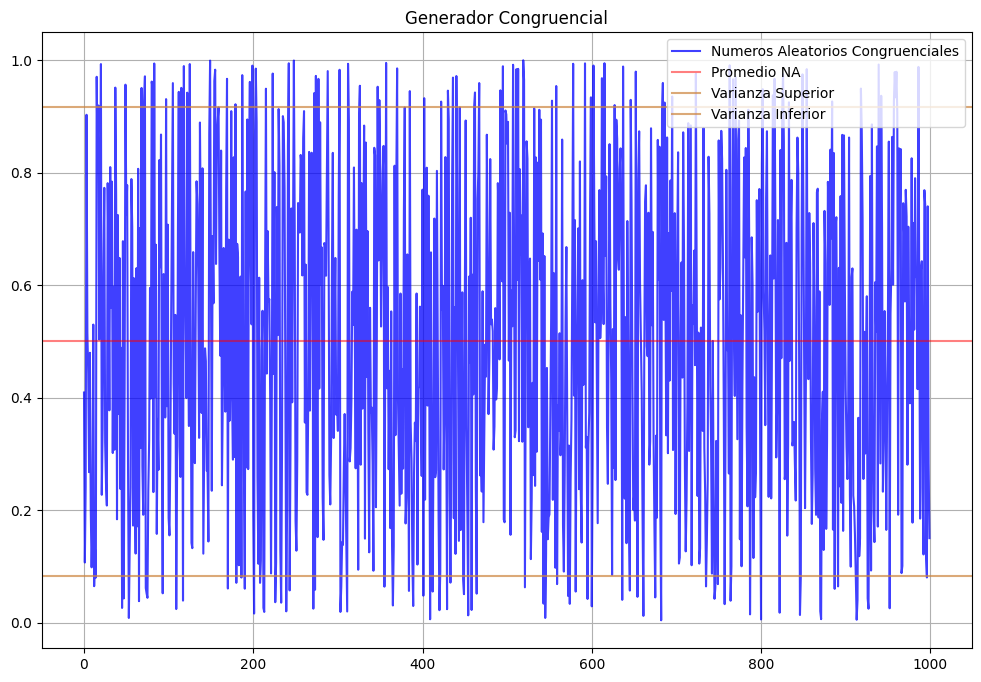

In [17]:
plt.figure(figsize=(12,8))
plt.plot(Gc, color='blue', alpha=0.75, label='Numeros Aleatorios Congruenciales')
plt.axhline(st.mean(Gc), color='red', alpha=0.5, label='Promedio NA')
plt.axhline(1-(1/12), color='peru', alpha=0.7, label='Varianza Superior')
plt.axhline((1/12), color='peru', alpha=0.7, label='Varianza Inferior')
plt.grid(True)
plt.legend()
plt.title('Generador Congruencial')
plt.show()

In [22]:
MediaNA = st.mean(Gc)
VarianzaNA = st.variance(Gc)
print('Med.T\tVar.T', sep='')
print(f'{1/2:.3f}','\t',f'{1/12:.3f}', sep='')
print('*'*15)
print('Med.E\tVar.E', sep='')
print(f'{st.mean(Gc):.3f}','\t',f'{st.variance(Gc):.3f}', sep='')

Med.T	Var.T
0.500	0.083
***************
Med.E	Var.E
0.501	0.084


**************************************************


Convergencia de la Media: 100%|██████████| 1000/1000 [00:00<00:00, 1299.04it/s]


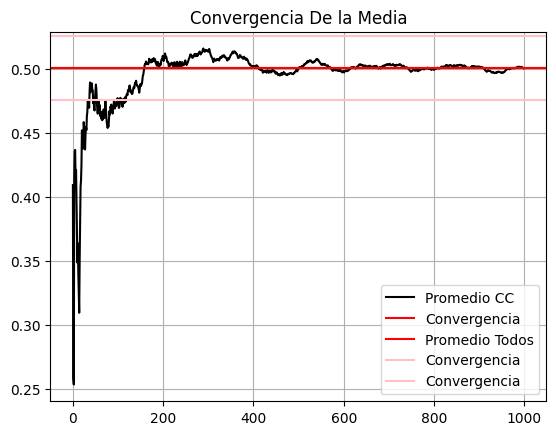

**************************************************


Convergencia de la Varianza: 100%|██████████| 1000/1000 [00:01<00:00, 723.48it/s]


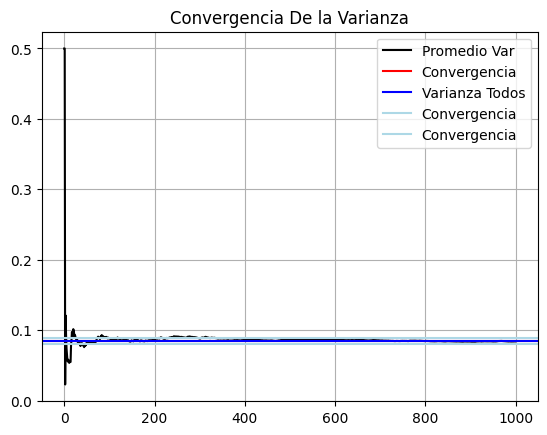

**************************************************


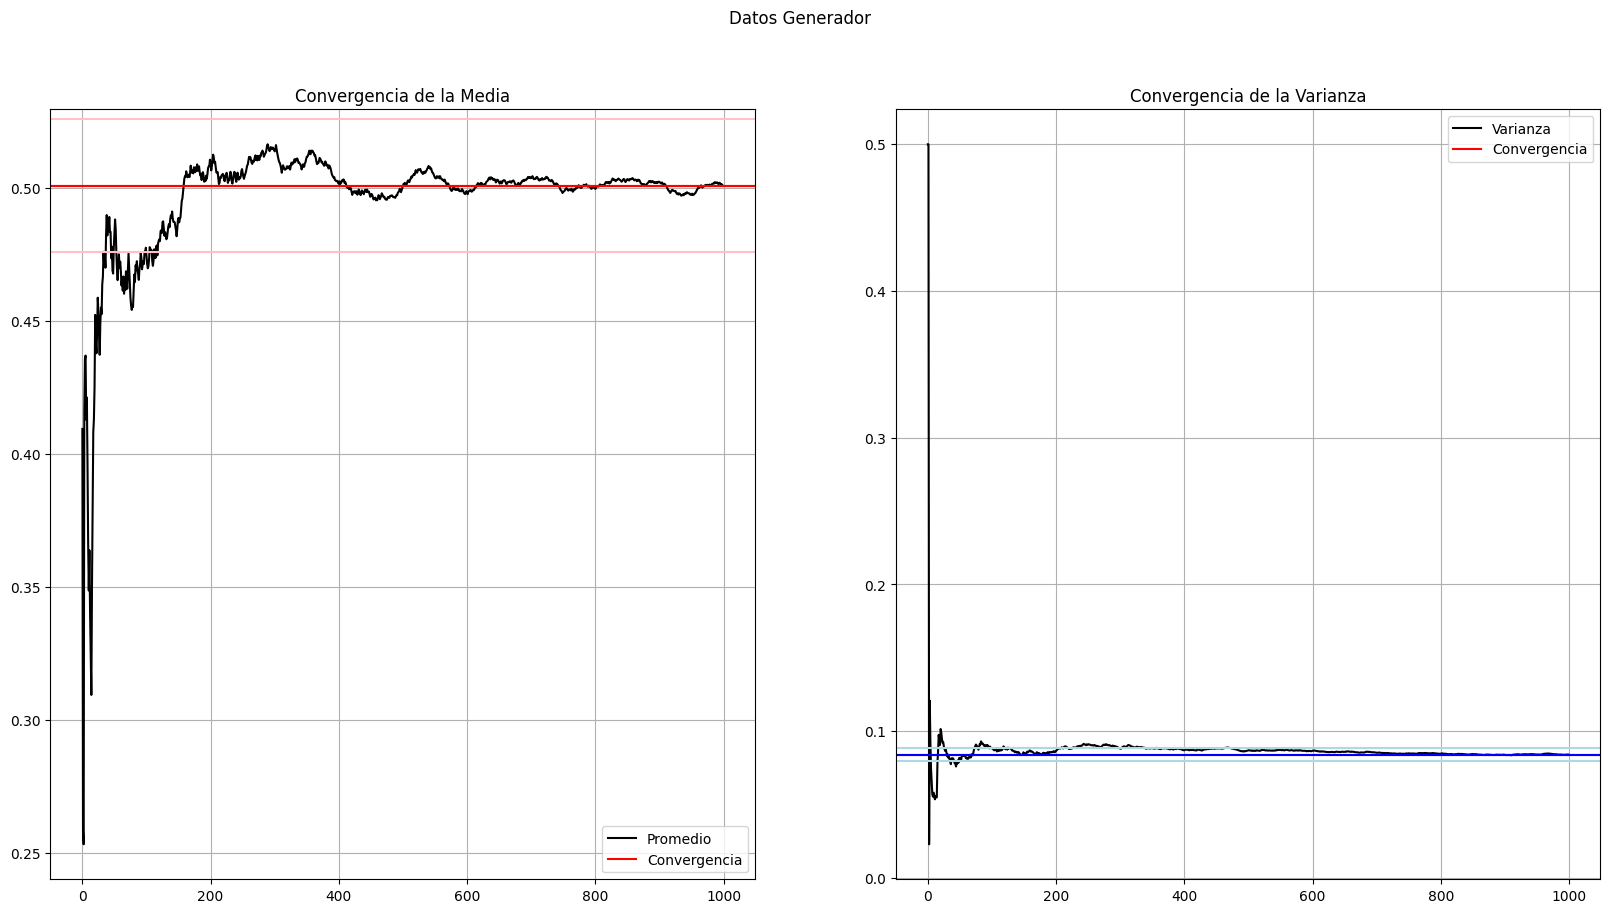

Generador Congruencial Mixto (Lineal) con numeros primos


In [24]:
print('*'*50)
tempm = []
promedio = []
for i in tqdm(Gc, desc ="Convergencia de la Media"):
    tempm.append(i)
    promedio.append(st.mean(tempm))
plt.plot(promedio, color='black', label='Promedio CC')
plt.axhline(promedio[-1], color='red', label='Convergencia')
plt.axhline(st.mean(tempm), color='red', label='Promedio Todos')
plt.axhline(promedio[-1]*0.95, color='pink', label='Convergencia')
plt.axhline(promedio[-1]*1.05, color='pink', label='Convergencia')
plt.legend()
plt.grid('on')
plt.title('Convergencia De la Media')
plt.show()
print('*'*50)
tempv = []
varianza = []
for i in tqdm(Gc, desc ="Convergencia de la Varianza"):
    tempv.append(i)
    if len(tempv)>2:
        varianza.append(st.variance(tempv))
    else:
        varianza.append(0.5)
plt.plot(varianza, color='black', label='Promedio Var')
plt.axhline(varianza[-1], color='red', label='Convergencia')
plt.axhline(st.variance(tempv), color='blue', label='Varianza Todos')
plt.axhline(varianza[-1]*0.95, color='lightblue', label='Convergencia')
plt.axhline(varianza[-1]*1.05, color='lightblue', label='Convergencia')
plt.legend()
plt.grid('on')
plt.title('Convergencia De la Varianza')
plt.show()
print('*'*50)

# Crear gráficas
fig, axs = plt.subplots(1, 2, figsize=(20, 10))  # Gráficas verticales

# Gráfica de la media
axs[0].plot(promedio, color='black', label='Promedio')
axs[0].axhline(promedio[-1], color='red', label='Convergencia')
axs[0].axhline(st.mean(tempm), color='red')
axs[0].axhline(promedio[-1]*0.95, color='pink')
axs[0].axhline(promedio[-1]*1.05, color='pink')
axs[0].set_title("Convergencia de la Media")
axs[0].grid('on')
axs[0].legend()

# Gráfica de la varianza
axs[1].plot(varianza, color='black', label='Varianza')
axs[1].axhline(varianza[-1], color='red', label='Convergencia')
axs[1].axhline(st.variance(tempv), color='blue')
axs[1].axhline(varianza[-1]*0.95, color='lightblue')
axs[1].axhline(varianza[-1]*1.05, color='lightblue')
axs[1].set_title("Convergencia de la Varianza")
axs[1].grid('on')
axs[1].legend()
# Aplicando un título general a la figura
fig.suptitle('Datos Generador')
plt.show()
print('Generador Congruencial Mixto (Lineal) con numeros primos')

In [25]:
generador =iter(Gc)

In [34]:
next(generador)

0.19888937668823142

### **Números de Mersenne**


Los números de Mersenne, nombrados en honor al matemático francés Marin Mersenne, son números enteros positivos de la forma $Mp = 2^p - 1$, donde $p$ también es un número primo.

En otras palabras, se obtienen al elevar dos a una potencia prima ($p$) y restarle uno.

Algunos ejemplos de números de Mersenne:

*   $M3 = 2^3 - 1 = 7$ (primo)
*   $M5 = 2^5 - 1 = 31$ (primo)
*   $M7 = 2^7 - 1 = 127$ (primo)
*   $M11 = {2}^{11} - 1 = 2047$ (compuesto)
*   $M13 = {2}^{13} - 1 = 8191$ (primo)

No todos los números de Mersenne son primos: solo aquellos donde p también es primo. De hecho, encontrar números primos de Mersenne es una tarea ardua en la que participan matemáticos y científicos de la computación alrededor del mundo.

¿Para qué sirven los números primos de Mersenne?

*   En criptografía: se utilizan para generar números aleatorios seguros y para crear algoritmos de cifrado robustos.
*   En la búsqueda de números primos: los números primos de Mersenne son utilizados para verificar la Conjetura de Mersenne, una importante proposición matemática.
*   En la teoría de la computación: se emplean para construir computadoras más rápidas y eficientes.

El mayor número primo de Mersenne conocido: A día de hoy, el mayor número primo de Mersenne conocido es $M82589933 - 1$, con 24.862.048 dígitos. Fue descubierto en diciembre de 2018.

In [ ]:
#Aplicar numeros de Mersenne